# **Практическая работа №10. Сравнение моделей классификации изображений и развертывание API**


## **Цель работы**


Провести сравнительный анализ ранее обученных моделей классификации изображений (работы 2-5), выбрать лучшую по метрикам качества, развернуть ее в виде API и создать пользовательский интерфейс с помощью Streamlit.

---

### **Раздел 1. Подготовка и анализ моделей**


1. Загрузить выбранный датасет для классификации изображений
2. Загрузить ранее обученные модели (из практических работ 2-5)
3. Сравнить модели по метрикам качества:
   - Точность (accuracy)
   - Полнота (recall)
   - Precision
   - F1-мера
   - Время инференса (Время, затрачиваемое моделью на формирование предсказания. Измеряется путём усреднения результатов на нескольких тысячах изображений)
4. Создать сводный DataFrame с результатами всех моделей
5. Визуализировать результаты сравнения с помощью графиков
6. Построить матрицы ошибок для каждой модели
7. Выбрать лучшую модель по F1-мере
8. Сохранить лучшую модель

In [42]:
print("1. Импорт библиотек\n")

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import tensorflow        as tf
from   tensorflow        import keras
from   google.colab      import files
from   pathlib           import Path

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import time
import os
import math
print("1. Библиотеки импортированы\n")

1. Импорт библиотек

1. Библиотеки импортированы



In [43]:
print("2. Загрузка датасета\n")
!mkdir -p data # -p —  создать, если не существует, и не ругаться, если уже есть
!curl -L -o data/flowers_dataset.zip "https://www.kaggle.com/api/v1/datasets/download/rahmasleam/flowers-dataset"
!unzip -q -o data/flowers_dataset.zip -d data/flowers_dataset

print("2. Структура датасета:\n")
!ls data/flowers_dataset/flower_photos


print("2. Датасет загружен\n")

2. Загрузка датасета

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  218M  100  218M    0     0  14.6M      0  0:00:14  0:00:14 --:--:-- 18.1M
2. Структура датасета:

daisy  dandelion  roses  sunflowers  tulips
2. Датасет загружен



In [44]:
DATASET_PATH = "data/flowers_dataset/flower_photos"

In [45]:
IMG_SIZE = (224, 224)  # стандарт для большинства моделей
FAST_MODE = True
# BUILD_CONF_MATRICES = False if FAST_MODE else True
BUILD_CONF_MATRICES = True
SAVE_PLOTS = True
BATCH_SIZE = 32

if FAST_MODE:
    MAX_SAMPLES = 2000
    TIMING_SAMPLES = 128
else:
    MAX_SAMPLES = None
    TIMING_SAMPLES = 1000


CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

MODEL_FILES = ["2.h5", "3_alexnet.keras", "3_cnn.keras", "4.keras", "5.keras"]
PREPROCESSING_MAP = {
    "3_alexnet": "standard",
    "default": "standard"
}

In [46]:
def get_preprocessing_fn(model_name):
    """Возвращает функцию preprocessing для конкретной модели"""
    preprocess_type = PREPROCESSING_MAP.get(model_name, "standard")

    if preprocess_type == "imagenet":
        # ImageNet preprocessing: mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
        def preprocess_imagenet(images):
            images = tf.cast(images, tf.float32) / 255.0
            mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
            std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
            images = (images - mean) / std
            return images
        return preprocess_imagenet

    elif preprocess_type == "tanh":
        # Tanh scaling: [-1, 1]
        def preprocess_tanh(images):
            images = tf.cast(images, tf.float32)
            images = (images / 127.5) - 1.0
            return images
        return preprocess_tanh

    else:
        # Standard: [0, 1]
        def preprocess_standard(images):
            images = tf.cast(images, tf.float32) / 255.0
            return images
        return preprocess_standard

In [47]:
# 1. Загрузка моделей
models_info = {}

for filename in MODEL_FILES:
    if not os.path.exists(filename):
        print(f"Файл не найден: {filename}")
        continue

    model_name = os.path.splitext(filename)[0]
    model = keras.models.load_model(filename, compile=False)

    input_shape = model.input_shape
    if len(input_shape) == 2:
        total_features = input_shape[1]
        img_size_1d = int(np.sqrt(total_features / 3))
        img_size = (img_size_1d, img_size_1d)
        needs_flatten = True
    else:
        img_size = (input_shape[1], input_shape[2])
        needs_flatten = False

    models_info[model_name] = {
        "model": model,
        "img_size": img_size,
        "needs_flatten": needs_flatten,
        "input_shape": input_shape,
        "file_name": filename,
        "preprocess_fn": get_preprocessing_fn(model_name)
    }

print(f"Загружено моделей: {len(models_info)}")

Загружено моделей: 5


In [48]:
# 2. Создание датасета с правильным preprocessing
dataset_cache = {}
label_cache = {}

def create_dataset_cached(img_size, needs_flatten, preprocess_fn, model_name, max_samples=None):
    cache_key = (img_size, needs_flatten, model_name, max_samples)

    if cache_key in dataset_cache:
        return dataset_cache[cache_key], label_cache[cache_key]

    ds = keras.utils.image_dataset_from_directory(
        DATASET_PATH,
        labels="inferred",
        label_mode="int",
        class_names=CLASS_NAMES,
        image_size=img_size,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    def preprocess(images, labels):
        images = preprocess_fn(images)
        if needs_flatten:
            images = tf.reshape(images, [tf.shape(images)[0], -1])
        return images, labels

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if max_samples is not None:
        num_batches = math.ceil(max_samples / BATCH_SIZE)
        ds = ds.take(num_batches)

    ds = ds.cache().prefetch(tf.data.AUTOTUNE)

    y_true_local = np.concatenate([y.numpy() for _, y in ds], axis=0)
    if max_samples is not None:
        y_true_local = y_true_local[:max_samples]

    dataset_cache[cache_key] = ds
    label_cache[cache_key] = y_true_local

    return ds, y_true_local

# Получаем y_true один раз
first_key = list(models_info.keys())[0]
first_info = models_info[first_key]
_, y_true_reference = create_dataset_cached(
    first_info["img_size"],
    first_info["needs_flatten"],
    first_info["preprocess_fn"],
    first_key,
    max_samples=MAX_SAMPLES
)

Found 3670 files belonging to 5 classes.


In [49]:
results = []
predictions_dict = {}
confusion_matrices = {}

for model_name, info in models_info.items():
    model = info["model"]
    img_size = info["img_size"]
    needs_flatten = info["needs_flatten"]
    preprocess_fn = info["preprocess_fn"]

    test_dataset, y_true = create_dataset_cached(
        img_size,
        needs_flatten,
        preprocess_fn,
        model_name,
        max_samples=MAX_SAMPLES
    )

    y_pred_proba = model.predict(test_dataset, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)[:len(y_true)]

    predictions_dict[model_name] = y_pred

    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    if BUILD_CONF_MATRICES:
        confusion_matrices[model_name] = confusion_matrix(y_true, y_pred)

    timing_dataset, timing_y = create_dataset_cached(
        img_size,
        needs_flatten,
        preprocess_fn,
        model_name,
        max_samples=TIMING_SAMPLES
    )

    start_time = time.perf_counter()
    _ = model.predict(timing_dataset, verbose=0)
    elapsed_time = time.perf_counter() - start_time
    inference_time_ms = (elapsed_time / len(timing_y)) * 1000

    results.append({
        "Модель": model_name,
        "Размер входа": f"{img_size[0]}×{img_size[1]}",
        "Accuracy": round(acc, 4),
        "Recall": round(rec, 4),
        "Precision": round(prec, 4),
        "F1-мера": round(f1, 4),
        "Инференс (мс/изобр)": round(inference_time_ms, 3)
    })

    # print(f"Acc={acc:.4f}, Rec={rec:.4f}, Prec={prec:.4f}, F1={f1:.4f}, Time={inference_time_ms:.3f}ms")

Found 3670 files belonging to 5 classes.
Found 3670 files belonging to 5 classes.
Found 3670 files belonging to 5 classes.
Found 3670 files belonging to 5 classes.
Found 3670 files belonging to 5 classes.
Found 3670 files belonging to 5 classes.
Found 3670 files belonging to 5 classes.
Found 3670 files belonging to 5 classes.
Found 3670 files belonging to 5 classes.


,Модель,Размер входа,Accuracy,Recall,Precision,F1-мера,Инференс (мс/изобр)
1,4,32×32,0.9010,0.9010,0.9336,0.9128,0.159
2,5,224×224,0.8105,0.8105,0.9027,0.8527,6.396
3,3_cnn,128×128,0.4075,0.4075,0.8251,0.4636,0.187
4,2,64×64,0.5045,0.5045,0.5699,0.4620,0.104
5,3_alexnet,128×128,0.0515,0.0515,0.1562,0.0775,1.048


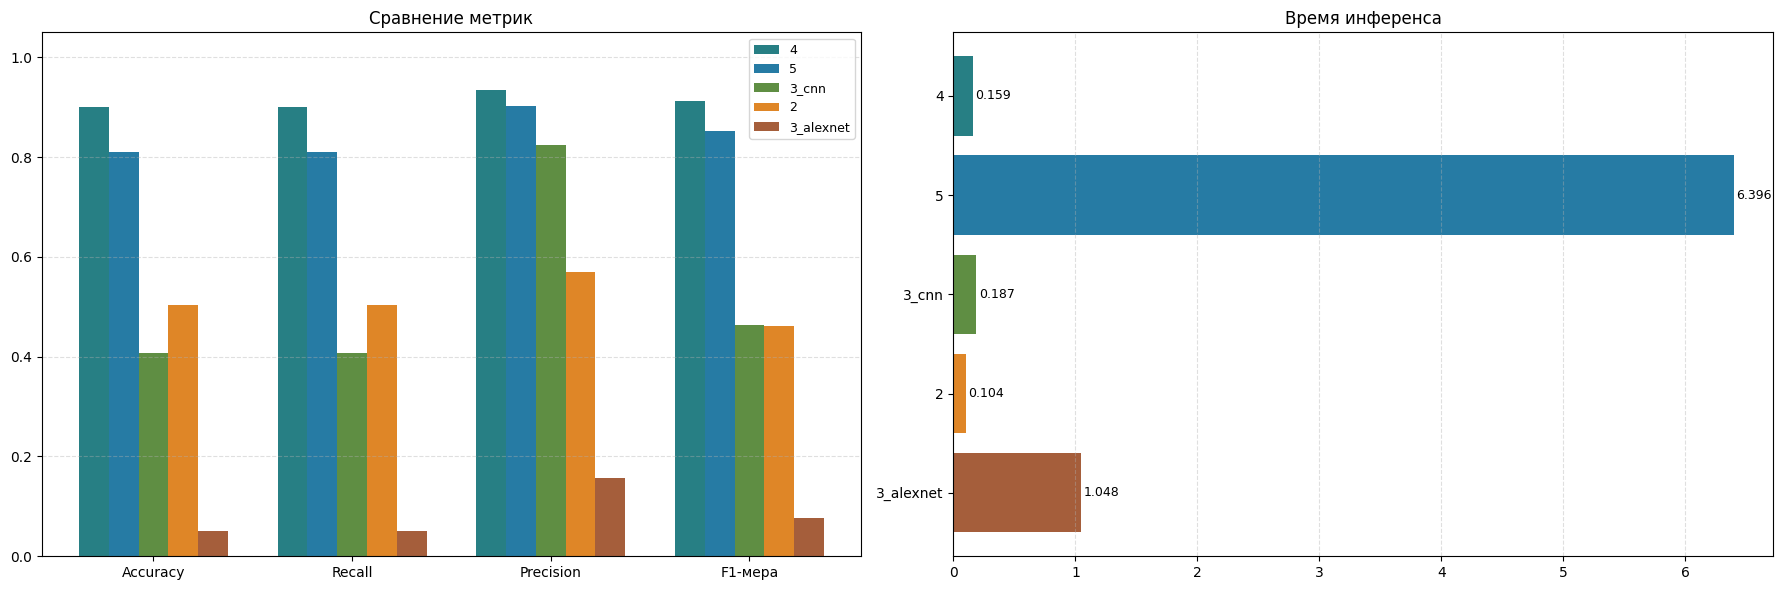

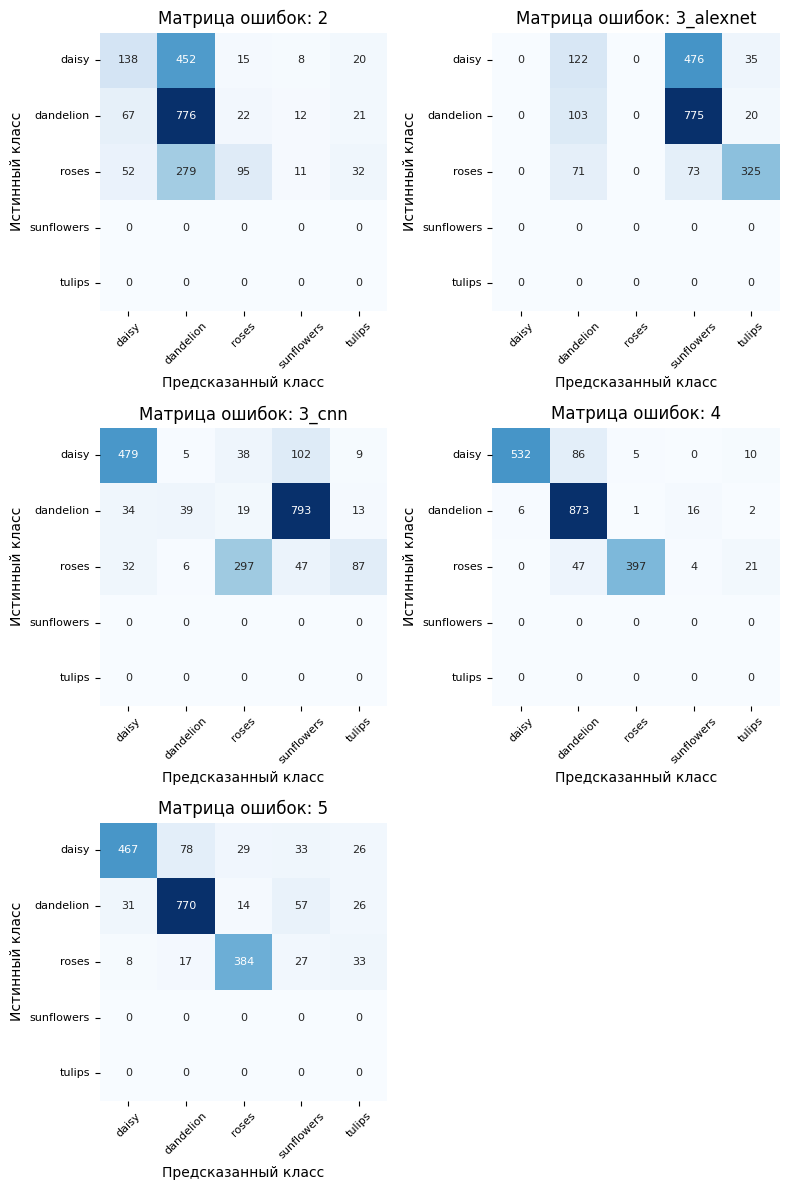

In [50]:
# # Матрицы ошибок для моделей
# confusion_matrices = {}

# # Подставь свои переменные с истинными и предсказанными метками
# confusion_matrices["flowersmodel"] = confusion_matrix(y_true_flowers, y_pred_flowers)
# confusion_matrices["AlexNet"] = confusion_matrix(y_true_alexnet, y_pred_alexnet)
# confusion_matrices["classifier"] = confusion_matrix(y_true_classifier, y_pred_classifier)

# 4. Таблица результатов
df_results = pd.DataFrame(results).sort_values("F1-мера", ascending=False).reset_index(drop=True)
df_results.index += 1
display(df_results)

# 5. Графики

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

metrics = ["Accuracy", "Recall", "Precision", "F1-мера"]
x = np.arange(len(metrics))
width = 0.15
colors = ["#01696f", "#006494", "#437a22", "#da7101", "#964219"]

for i, row in df_results.iterrows():
    vals = [row[m] for m in metrics]
    offset = (i - 1 - (len(df_results) - 1) / 2) * width
    axes[0].bar(
        x + offset,
        vals,
        width,
        label=row["Модель"],
        color=colors[(i - 1) % len(colors)],
        alpha=0.85
    )

axes[0].set_title("Сравнение метрик")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

bars = axes[1].barh(
    df_results["Модель"],
    df_results["Инференс (мс/изобр)"],
    color=colors[:len(df_results)],
    alpha=0.85
)
axes[1].set_title("Время инференса")
axes[1].invert_yaxis()
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

for bar, val in zip(bars, df_results["Инференс (мс/изобр)"]):
    axes[1].text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
if SAVE_PLOTS:
    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# Матрицы ошибок
if BUILD_CONF_MATRICES:
    num_models = len(confusion_matrices)
    cols = 2
    rows = math.ceil(num_models / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(8, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[idx],
            cbar=False,
            annot_kws={"size": 8}
        )
        axes[idx].set_title(f"Матрица ошибок: {model_name}")
        axes[idx].set_xlabel("Предсказанный класс")
        axes[idx].set_ylabel("Истинный класс")
        axes[idx].tick_params(axis="x", rotation=45, labelsize=8)
        axes[idx].tick_params(axis="y", rotation=0, labelsize=8)

    for idx in range(num_models, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()

In [51]:
# 7. Лучшая модель
best_row = df_results.iloc[0]
best_name = best_row["Модель"]
best_model = models_info[best_name]["model"]

print(f"\nЛучшая модель: {best_name}")
print(f"F1-мера: {best_row['F1-мера']:.4f}")

best_model.save("best_classification_model.keras")
print("Сохранено: best_classification_model.keras")

# Сохраняем информацию о preprocessing для API
model_info_text = f"""ЛУЧШАЯ МОДЕЛЬ: {best_name}
INPUT SHAPE: {models_info[best_name]['input_shape']}
IMG SIZE: {models_info[best_name]['img_size']}
FLATTEN: {models_info[best_name]['needs_flatten']}
PREPROCESSING: {PREPROCESSING_MAP.get(best_name, 'standard')}

F1-мера: {best_row['F1-мера']:.4f}
Accuracy: {best_row['Accuracy']:.4f}

КЛАССЫ: {CLASS_NAMES}
"""

with open("model_info.txt", "w") as f:
    f.write(model_info_text)

print("Сохранено: model_info.txt")


Лучшая модель: 4
F1-мера: 0.9128
Сохранено: best_classification_model.keras
Сохранено: model_info.txt


In [52]:
from tensorflow import keras

model = keras.models.load_model("best_classification_model.keras", compile=False)
model.export("exported_model")
print("Saved to exported_model/")

Saved artifact at 'exported_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134290743760400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134290743763472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134287845627984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134287845624528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134290743763280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134287845622992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134287845626640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134287845628176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134287845625104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134287845628752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134287842263120: 

In [53]:
import shutil
shutil.make_archive('exported_model', 'zip', 'exported_model')

'/content/exported_model.zip'

---

### **Раздел 2. Развертывание API**


1. Создать FastAPI приложение для обработки запросов с изображениями
2. Реализовать предобработку загружаемых изображений
3. Реализовать эндпоинт для классификации изображений
4. Добавить возврат предсказанного класса и вероятностей по всем классам
5. Создать файл requirements.txt с необходимыми зависимостями
6. Развернуть API на любом сервере с доступом из глобальной сети

#### **Инструкция по развёртыванию на Render.com**



**Шаги:**

1. **Репозиторий проекта:**
   - Создайте репозиторий на GitHub, содержащий файлы `main.py`, `requirements.txt`, `best_classification_model` и `scaler.pkl` (при наличии).

2. **Регистрация на Render.com:**
   - Зарегистрируйтесь на [Render.com](https://render.com/).

3. **Создание нового веб-сервиса:**
   - В панели управления Render.com создайте новый веб-сервис, связав его с вашим репозиторием.

4. **Настройка версии Python:**
   - В разделе **Environment Variables** (Переменные окружения) добавьте новую переменную:
     - **Key (Ключ):** `PYTHON_VERSION`
     - **Value (Значение):** `3.12.1`
   - Это позволит Render.com использовать указанную версию Python при сборке и запуске приложения.

5. **Настройка сервиса:**
   - Укажите команду запуска приложения: `uvicorn main:app --host 0.0.0.0 --port $PORT`.
   - Убедитесь, что в `requirements.txt` перечислены все необходимые зависимости.

6. **Развёртывание:**
   - Запустите процесс развёртывания и дождитесь его завершения.
   - После успешного развёртывания ваш API будет доступен по выделенному адресу.

#### **Инструкция по развёртыванию Hugging Face Spaces (если возникли пролемы с доступом к Render.com)**


**Шаги:**

1. **Регистрация:**
   - Зарегистрируйтесь на [huggingface.co](https://huggingface.co) (бесплатно, без карты).
   - Подтвердите e-mail.

2. **Создание нового Space:**
   - На главной странице нажмите на аватар → **New Space**.
   - Заполните поля:
     - **Space name:** `имя_проекта_backend`.
     - **License:** `mit` (или любая на ваш выбор).
     - **SDK:** выбрать **Docker** → **Blank**.
     - **Visibility:** `Public`.
     - **Hardware:** `CPU basic · 2 vCPU · 16 GB · FREE`.

3. **Push репозитория в Hugging Face:**
   - После создания Space Hugging Face даст адрес Git-репозитория вида `https://huggingface.co/spaces/ВАШ_USERNAME/california-regression`.
   - Добавьте его как удалённый репозиторий в ваш локальный проект:
   ```bash
   git remote add hf https://huggingface.co/spaces/ВАШ_USERNAME/ВАШ_РЕПОЗИТОРИЙ
   git push hf main
   ```
   - При push потребуется логин Hugging Face и **Access Token** (создаётся в Settings → Access Tokens с правом `write`).

4. **Автоматическая сборка:**
   - Hugging Face автоматически обнаружит `Dockerfile` и запустит сборку.
   - Процесс сборки занимает **5–10 минут** (установка TensorFlow — самая долгая часть).
   - Статус можно отслеживать на вкладке **Logs** в интерфейсе Space.

5. **Получение публичного URL:**
   - После успешного деплоя API доступен по адресу:
     ```
     https://ВАШ_USERNAME-ИМЯ-ПРОЕКТА.hf.space/predict
     ```
   - Этот URL работает 24/7 без усыпления, в отличие от бесплатных тарифов Render.com.

---

**Структура проекта для развёртывания на Hugging Face**

```
main.py
requirements.txt
Dockerfile
README.md
best_classification_model.h5
```

---

**Содержимое Dockerfile**


```dockerfile
# Используем официальный образ Python 3.12 (slim-версия для экономии места)
FROM python:3.12-slim

# Устанавливаем рабочую директорию внутри контейнера
WORKDIR /app

# Копируем файл зависимостей
COPY requirements.txt .

# Устанавливаем зависимости
RUN pip install --no-cache-dir --upgrade pip && \
    pip install --no-cache-dir -r requirements.txt

# Копируем все файлы проекта в контейнер
COPY . .

# Открываем порт 7860 (стандартный порт для Hugging Face Spaces)
EXPOSE 7860

# Команда запуска приложения
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]
```

---


#### **Ответ:**

https://rsbtv-flowers-api-backend.hf.space/docs#/

---

### **Раздел 3. Создание интерфейса на Streamlit**



1. Разработать Streamlit-приложение со следующими функциями:
   - Возможность загрузки изображения пользователем
   - Возможность рисования изображения на холсте
   - Предобработка изображения перед отправкой на API
   - Отображение результатов классификации
   - Визуализация распределения вероятностей по классам
2. Развернуть Streamlit-приложение на платформе Streamlit Cloud

#### **Ответ:**

https://flowersapp-4urhpz4rfymynfxy9dglgd.streamlit.app

---

### **Раздел 4. Документация и публикация проекта**


1. Создать GitHub-репозиторий со структурой:
   - Модели (сохраненная лучшая модель)
   - API (код и зависимости)
   - Интерфейс (код Streamlit-приложения)
   - Документация (README.md)
   - Требования (requirements.txt)
2. Добавить в README.md:
   - Описание проекта и используемого датасета
   - Описание сравниваемых моделей
   - Таблицу с результатами сравнения моделей
   - Визуализации результатов
   - Инструкции по локальному развертыванию
   - Ссылки на развернутый API и Streamlit-приложение
   - Примеры использования API
3. Предоставить ссылки на:
   - GitHub-репозиторий
   - Публичный API для отправки POST-запросов
   - Streamlit-интерфейс для взаимодействия с моделью

#### **Ответ:**

https://github.com/rsbtv/flowers_app

---

#### **Пример**

- **GitHub-репозиторий:** https://github.com/Alexandre77777/dpo_classification.git

- **Публичный API для отправки POST-запросов:** https://dpo-classification.onrender.com/predict/

- **Streamlit-интерфейс для взаимодействия с моделью:** https://dpo-classification.streamlit.app/
